In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Experiment 2

In [14]:
scan_rates = [20, 50, 80, 125, 200]
exp_2 = {sr: pd.read_csv(f"data/exp2-{sr}.txt", sep=",", names=["Potential", "Current"]) for sr in scan_rates}

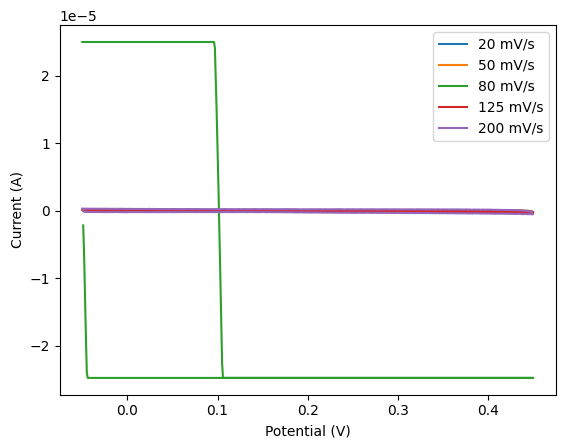

In [15]:
fig, ax = plt.subplots()
for sr, df in exp_2.items():
    ax.plot(df["Potential"], df["Current"], label=f"{sr} mV/s")
    ax.legend()
    ax.set_xlabel("Potential (V)")
    ax.set_ylabel("Current (A)")

## Experiment 3

In [10]:
times = [0, 5, 10, 20]
exp_3 = {t: pd.read_csv(f"datar/exp3-{t}.txt", sep=",", names=["Potential", "Current"]) for t in times}

In [11]:
cv_max_3 = np.array([float(v['Current'].max()) for v in exp_3.values()])
cv_min_3 = np.array([float(v['Current'].min()) for v in exp_3.values()])

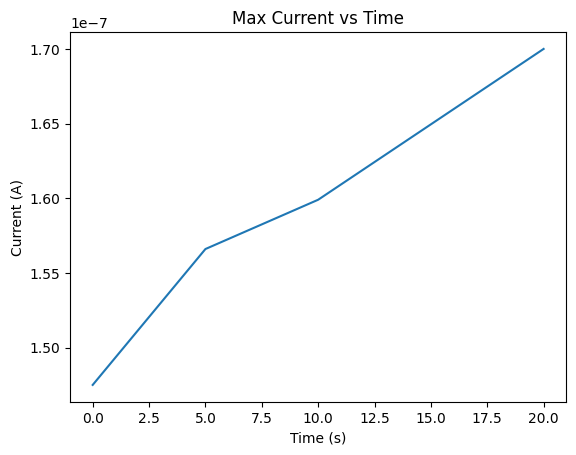

In [12]:
fig, ax = plt.subplots()
ax.plot(times, cv_max_3, label="Max Current")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Current (A)")
ax.set_title("Max Current vs Time")
plt.show()

## Experiment 4

In [13]:
labels = [1, 2, 3]
exp_4a = {l: pd.read_csv(f"datar/exp4-a{l}.txt", sep=",", index_col=0, names=[f"{l} Current"]) for l in labels}
exp_4a = pd.concat(exp_4a.values(), axis=1)
exp_4b = {l: pd.read_csv(f"datar/exp4-b{l}.txt", sep=",", index_col=0, names=[f"{l} Current"]) for l in labels}
exp_4b = pd.concat(exp_4b.values(), axis=1)

exp_4a["Mean"] = exp_4a.mean(axis=1)
exp_4a["STD"] = exp_4a.std(axis=1)
exp_4a["RSD"] = exp_4a["STD"] / abs(exp_4a["Mean"]) * 100


exp_4b["Mean"] = exp_4b.mean(axis=1)
exp_4b["STD"] = exp_4b.std(axis=1)
exp_4b["RSD"] = exp_4b["STD"] / abs(exp_4b["Mean"]) * 100

print(f'Exp 4: Intra Electrode RSD: {exp_4a["RSD"].mean():.2f}%')
print(f'Exp 4: Inter Electrode RSD: {exp_4b["RSD"].mean():.2f}%')

Exp 4: Intra Electrode RSD: 2.77%
Exp 4: Inter Electrode RSD: 6.18%


## Experiment 5

In [26]:
concentrations = ["1E-5", "5E-5", "1E-4"] 
concentrationsr = ["1E-6", "5E-6"] 
exp_5 = {}
for c in concentrationsr:
    exp_5[c] = pd.read_csv(f"datar/exp5-{c}.txt", sep=",", names=["Potential", "Current"])
for c in concentrations:
    exp_5[c] = pd.read_csv(f"data/exp5-{c}.txt", sep=",", names=["Potential", "Current"])

cv_max_5 = np.array([float(v['Current'].max()) for v in exp_5.values()])
cv_min_5 = np.array([float(v['Current'].min()) for v in exp_5.values()])

In [31]:
concs = [float(key) for key in exp_5.keys()]
concs

[1e-06, 5e-06, 1e-05, 5e-05, 0.0001]

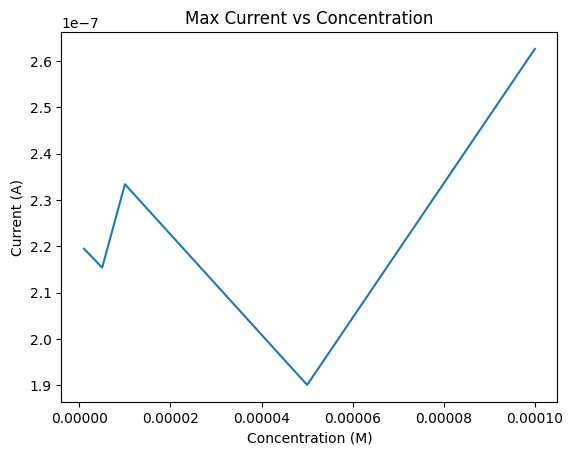

In [56]:
fig, ax = plt.subplots()
ax.plot(concs, cv_max_5, label="Max Current")
ax.set_xlabel("Concentration (M)")
ax.set_ylabel("Current (A)")
ax.set_title("Max Current vs Concentration")
plt.show()

## Experiment 6

In [57]:
exp_6 = {l: pd.read_csv(f"datar/exp6-{l}.txt", sep=",", index_col=0, names=[f"Current"]) for l in labels}
cv_max_6 = [float(v["Current"].max()) for v in exp_6.values()]
cv_max_6_ids = [float(v["Current"].idxmax()) for v in exp_6.values()]

In [58]:
cv_max_6

[1.608e-07, 1.657e-07, 1.685e-07]

In [59]:
cv_max_6_ids

[0.11, 0.12, -0.05]

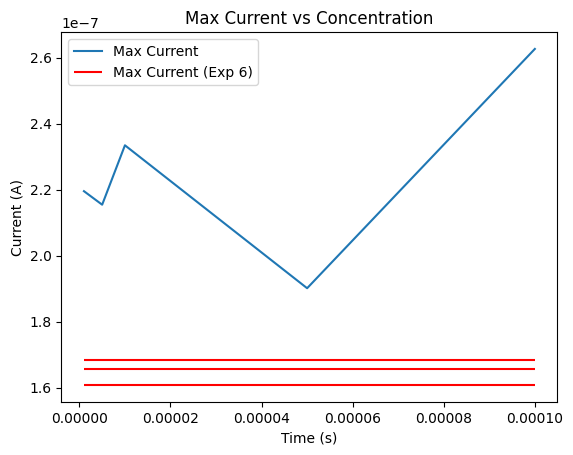

In [66]:
fig, ax = plt.subplots()
ax.plot(concs, cv_max_5, label="Max Current")
ax.hlines(cv_max_6, xmin=min(concs), xmax=max(concs) ,label="Max Current (Exp 6)", color = 'r')
ax.set_xlabel("Time (s)")
ax.set_ylabel("Current (A)")
ax.set_title("Max Current vs Concentration")
ax.legend()
plt.show()